In [4]:
%cd /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev
!lamin connect emoeller80281/dev

/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev


132.46s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


→ connected lamindb: emoeller80281/dev


In [5]:
import lamindb as ln
import bionty as bt

# inspect the available public ontology versions
bt.Source.to_dataframe()

→ connected lamindb: emoeller80281/dev
! truncated query result to limit=20 Source objects


,uid,entity,organism,name,version,in_db,currently_used,description,url,md5,source_website,is_locked,created_at,branch_id,created_on_id,space_id,created_by_id,run_id,dataframe_artifact_id
id,,,,,,,,,,,,,,,,,,,
43,5JnVODh4,BioSample,all,ncbi,2023-09,False,True,NCBI BioSample attributes,s3://bionty-assets/df_all__ncbi__2023-09__BioS...,None,https://www.ncbi.nlm.nih.gov/biosample/docs/at...,False,2026-09-22 19:57:01.342000+00:00,1,1,1,1,None,None
42,7au3ZQrD,bionty.Ethnicity,human,hancestro,2025-10-14,False,True,Human Ancestry Ontology,http://purl.obolibrary.org/obo/hancestro/relea...,None,https://github.com/EBISPOT/hancestro,False,2026-09-22 19:57:01.342000+00:00,1,1,1,1,None,None
41,6na9vRls,bionty.DevelopmentalStage,mouse,mmusdv,2025-01-23,False,True,Mouse Developmental Stages,https://github.com/obophenotype/developmental-...,None,https://github.com/obophenotype/developmental-...,False,2026-09-22 19:57:01.342000+00:00,1,1,1,1,None,None
40,7JO1x6p1,bionty.DevelopmentalStage,human,hsapdv,2025-01-23,False,True,Human Developmental Stages,https://github.com/obophenotype/developmental-...,None,https://github.com/obophenotype/developmental-...,False,2026-09-22 19:57:01.342000+00:00,1,1,1,1,None,None
39,ugaIoIlj,Drug,all,dron,2024-08-05,False,False,Drug Ontology,http://purl.obolibrary.org/obo/dron/releases/2...,None,https://bioportal.bioontology.org/ontologies/DRON,False,2026-09-22 19:57:01.342000+00:00,1,1,1,1,None,None
38,6bSx9Bpd,Drug,all,chebi,2026-09-01,False,True,Chemical Entities of Biological Interest,s3://bionty-assets/df_all__chebi__2026-09-01__...,None,https://www.ebi.ac.uk/chebi/,False,2026-09-22 19:57:01.342000+00:00,1,1,1,1,None,None
37,3rm9aOzL,BFXPipeline,all,lamin,1.0.0,False,True,Bioinformatics Pipeline,s3://bionty-assets/df_all__lamin__1.0.0__BFXpi...,None,https://lamin.ai,False,2026-09-22 19:57:01.342000+00:00,1,1,1,1,None,None
36,310u2HLQ,bionty.Pathway,all,pw,2026-05-16,False,False,Pathway Ontology,http://purl.obolibrary.org/obo/pw/2026-05-16/p...,None,https://www.ebi.ac.uk/ols/ontologies/pw,False,2026-09-22 19:57:01.342000+00:00,1,1,1,1,None,None
35,2UZHts8n,bionty.Pathway,all,go,2025-10-10,False,True,Gene Ontology,http://purl.obolibrary.org/obo/go/releases/202...,None,http://geneontology.org,False,2026-09-22 19:57:01.342000+00:00,1,1,1,1,None,None


In [6]:
# inspect which ontology version we're about to import
bt.Source.get(entity="bionty.CellType", currently_used=True)

Source(uid='dq7QgcSP', entity='bionty.CellType', organism='all', name='cl', version='2026-06-08', in_db=False, currently_used=True, description='Cell Ontology', url='http://purl.obolibrary.org/obo/cl/releases/2026-06-08/cl.owl', md5=None, source_website='https://obophenotype.github.io/cell-ontology', branch_id=1, created_on_id=1, space_id=1, created_by_id=1, run_id=None, dataframe_artifact_id=None, created_at=2026-09-22 19:57:01 UTC, is_locked=False)

This is now your in-house cell type ontology in which you can add & modify records as you like. It’s a registry just like Artifact or Record.

In [7]:
# populate the database with a public ontology
bt.CellType.import_source()

# let's also populate the Gene registry with human and mouse genes
bt.Gene.import_source(organism="human")
bt.Gene.import_source(organism="mouse")

... synchronizing df_all__cl__2026-06-08__CellType.parquet: 100.0%
... synchronizing df_vertebrates__ensembl__release-116__Organism.parquet: 100.0%
... synchronizing df_human__ensembl__release-116__Gene.parquet: 100.0%
→ starting creation of 91743 Gene records in batches of 10000
... synchronizing df_mouse__ensembl__release-116__Gene.parquet: 100.0%
→ starting creation of 78718 Gene records in batches of 10000


## Access records in in-house registries

Search key words:

In [8]:
bt.CellType.search("gamma-delta T").to_dataframe().head(2)

,uid,name,ontology_id,abbr,synonyms,description,is_locked,created_at,branch_id,created_on_id,space_id,created_by_id,run_id,source_id
id,,,,,,,,,,,,,,
780,1HuNn2EPaZnqWk,gamma-delta T cell,CL:0000798,None,gamma-delta T lymphocyte|gamma-delta T-lymphoc...,A T Cell That Expresses A Gamma-Delta T Cell R...,False,2026-09-22 20:09:21.674000+00:00,1,1,1,1,None,26
781,70lHcCNwY7Kxtr,immature gamma-delta T cell,CL:0000799,None,immature gamma-delta T-cell|immature gamma-del...,A Gamma-Delta T Cell That Has An Immature Phen...,False,2026-09-22 20:09:21.674000+00:00,1,1,1,1,None,26


Or look up with auto-complete

In [9]:
cell_types = bt.CellType.lookup()
hsc_record = cell_types.hematopoietic_stem_cell
hsc_record

CellType(uid='2U8xapxuL7VEqb', name='hematopoietic stem cell', ontology_id='CL:0000037', abbr=None, synonyms='hemopoietic stem cell|blood forming stem cell', description='A Stem Cell From Which All Cells Of The Lymphoid And Myeloid Lineages Develop, Including Blood Cells And Cells Of The Immune System. Hematopoietic Stem Cells Lack Cell Markers Of Effector Cells (Lin-Negative). Lin-Negative Is Defined By Lacking One Or More Of The Following Cell Surface Markers: Cd2, Cd3 Epsilon, Cd4, Cd5 ,Cd8 Alpha Chain, Cd11B, Cd14, Cd19, Cd20, Cd56, Ly6G, Ter119.', branch_id=1, created_on_id=1, space_id=1, created_by_id=1, run_id=None, source_id=26, created_at=2026-09-22 20:09:21 UTC, is_locked=False)

Filter by fields and relationships:

In [10]:
gdt_cell = bt.CellType.get(ontology_id="CL:0000798")
gdt_cell

CellType(uid='1HuNn2EPaZnqWk', name='gamma-delta T cell', ontology_id='CL:0000798', abbr=None, synonyms='gamma-delta T lymphocyte|gamma-delta T-lymphocyte|gamma-delta T-cell|gammadelta T cell', description='A T Cell That Expresses A Gamma-Delta T Cell Receptor Complex.', branch_id=1, created_on_id=1, space_id=1, created_by_id=1, run_id=None, source_id=26, created_at=2026-09-22 20:09:21 UTC, is_locked=False)

View the ontological hierarchy:

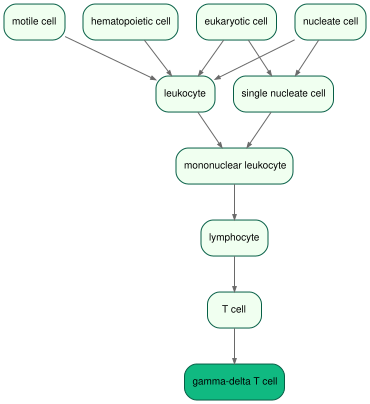

In [11]:
gdt_cell.view_parents()  # pass with_children=True to also view children

Or access the parents and children directly:



In [12]:
gdt_cell.parents.to_dataframe()

,uid,name,ontology_id,abbr,synonyms,description,is_locked,created_at,branch_id,created_on_id,space_id,created_by_id,run_id,source_id
id,,,,,,,,,,,,,,
83,22LvKd01YyNA1a,T cell,CL:0000084,None,T-cell|T lymphocyte|T-lymphocyte,A Type Of Lymphocyte Whose Defining Characteri...,False,2026-09-22 20:09:21.624000+00:00,1,1,1,1,None,26


It is also possible to recursively query parents or children, getting direct parents (children), their parents, and so forth.

In [13]:
gdt_cell.query_parents().to_dataframe()

,uid,name,ontology_id,abbr,synonyms,description,is_locked,created_at,branch_id,created_on_id,space_id,created_by_id,run_id,source_id
id,,,,,,,,,,,,,,
1303,u3sr1GdfF3aIV9,nucleate cell,CL:0002242,None,None,A Cell Containing At Least One Nucleus.,False,2026-09-22 20:09:21.716000+00:00,1,1,1,1,None,26
967,4Ilrnj9ULJe69Z,hematopoietic cell,CL:0000988,None,haemopoietic cell|haematopoietic cell|hemopoie...,A Cell Of A Hematopoietic Lineage.,False,2026-09-22 20:09:21.688000+00:00,1,1,1,1,None,26
822,2Jgr5Xx4RSJlVB,mononuclear leukocyte,CL:0000842,None,mononuclear cell,A Leukocyte With A Single Non-Segmented Nucleu...,False,2026-09-22 20:09:21.679000+00:00,1,1,1,1,None,26
721,3VEAlFdi0Fh4OT,leukocyte,CL:0000738,None,leucocyte|WBC|white blood cell,An Achromatic Cell Of The Myeloid Or Lymphoid ...,False,2026-09-22 20:09:21.670000+00:00,1,1,1,1,None,26
529,X6c7osZ5A24bW2,lymphocyte,CL:0000542,None,None,A Lymphocyte Is A Leukocyte Commonly Found In ...,False,2026-09-22 20:09:21.656000+00:00,1,1,1,1,None,26
250,4WnpvUTHNi32Fp,eukaryotic cell,CL:0000255,None,None,Any Cell That In Taxon Some Eukaryota.,False,2026-09-22 20:09:21.638000+00:00,1,1,1,1,None,26
221,2cXC7cgFM5zNgH,single nucleate cell,CL:0000226,None,None,A Cell With A Single Nucleus.,False,2026-09-22 20:09:21.633000+00:00,1,1,1,1,None,26
214,2K93w3xOD2sghG,motile cell,CL:0000219,None,None,A Cell That Moves By Its Own Activities.,False,2026-09-22 20:09:21.633000+00:00,1,1,1,1,None,26
83,22LvKd01YyNA1a,T cell,CL:0000084,None,T-cell|T lymphocyte|T-lymphocyte,A Type Of Lymphocyte Whose Defining Characteri...,False,2026-09-22 20:09:21.624000+00:00,1,1,1,1,None,26


In [14]:
gdt_cell.query_children().to_dataframe()

! truncated query result to limit=20 CellType objects


,uid,name,ontology_id,abbr,synonyms,description,is_locked,created_at,branch_id,created_on_id,space_id,created_by_id,run_id,source_id
id,,,,,,,,,,,,,,
3005,5XXsI4tmojLPen,cycling gamma-delta T cell,CL:4033072,None,proliferating gamma-delta T cell,A(N) Gamma-Delta T Cell That Is Cycling.,False,2026-09-22 20:09:21.979000+00:00,1,1,1,1,None,26
2176,1rmso5r0areUcW,V1delta gamma-delta T cell,CL:0020001,None,None,A Mature Gamma-Delta T Cell With T Cell Recept...,False,2026-09-22 20:09:21.783000+00:00,1,1,1,1,None,26
1573,E2koIf0laWBvVp,Vgamma5-negative CD8-alpha alpha positive gamm...,CL:0002514,None,tgd.vg5-.IEL,A Cd8-Alpha Alpha Positive Gamma-Delta Intraep...,False,2026-09-22 20:09:21.735000+00:00,1,1,1,1,None,26
1572,1jlK4jJ9cfpNl2,Vgamma5-positive CD8-alpha alpha positive gamm...,CL:0002513,None,tgd.vg5+.IEL,A Cd8-Alpha Alpha Positive Gamma-Delta Intraep...,False,2026-09-22 20:09:21.735000+00:00,1,1,1,1,None,26
1476,6JxpxGgMxEOE0s,"mature Vgamma1.1-positive, Vdelta6.3-positive ...",CL:0002416,None,mature Vg1.1+Vd6.3+ T cell,"A Vgamma1.1-Positive, Vdelta6.3-Positive Thymo...",False,2026-09-22 20:09:21.726000+00:00,1,1,1,1,None,26
1475,2SYX59uOSAhgLG,"immature Vgamma1.1-positive, Vdelta6.3-positiv...",CL:0002415,None,immature Vg1.1+Vd6.3+ T cell,"A Vgamma1.1-Positive, Vdelta6.3-Positive Thymo...",False,2026-09-22 20:09:21.726000+00:00,1,1,1,1,None,26
1474,5pDjyjfFx2qcX8,"immature Vgamma1.1-positive, Vdelta6.3-negativ...",CL:0002414,None,None,"A Vgamma1.1-Positive, Vdelta6.3-Negative Thymo...",False,2026-09-22 20:09:21.726000+00:00,1,1,1,1,None,26
1473,4cYNDr25MbvIM8,"mature Vgamma1.1-positive, Vdelta6.3-negative ...",CL:0002413,None,None,"A Vgamma1.1-Positive, Vdelta6.3-Negative Thymo...",False,2026-09-22 20:09:21.726000+00:00,1,1,1,1,None,26
1472,6vYlL7zk77kX4K,"Vgamma1.1-positive, Vdelta6.3-positive thymocyte",CL:0002412,None,Vg1.1+Vd6.3+ T cell,A Gamma-Delta Receptor That Expresses Vgamma1....,False,2026-09-22 20:09:21.726000+00:00,1,1,1,1,None,26


## Validate & standardize
Simple validation of an iterable of values works like so:

In [15]:
bt.CellType.validate(["fat cell", "blood forming stem cell"])

! 2 unique terms (100.00%) are not validated for name: 'fat cell', 'blood forming stem cell'


array([False, False])

Because these values don’t comply with the registry, they’re not validated!

You can easily convert these values to validated standardized names based on synonyms like so:

In [16]:
bt.CellType.standardize(["fat cell", "blood forming stem cell"])

['adipocyte', 'hematopoietic stem cell']

Alternatively, you can use `.from_values()`, which will only ever return validated records and automatically standardize under-the-hood:

In [17]:
bt.CellType.from_values(["fat cell", "blood forming stem cell"])

SQLRecordList([CellType(uid='2U8xapxuL7VEqb', name='hematopoietic stem cell', ontology_id='CL:0000037', abbr=None, synonyms='hemopoietic stem cell|blood forming stem cell', description='A Stem Cell From Which All Cells Of The Lymphoid And Myeloid Lineages Develop, Including Blood Cells And Cells Of The Immune System. Hematopoietic Stem Cells Lack Cell Markers Of Effector Cells (Lin-Negative). Lin-Negative Is Defined By Lacking One Or More Of The Following Cell Surface Markers: Cd2, Cd3 Epsilon, Cd4, Cd5 ,Cd8 Alpha Chain, Cd11B, Cd14, Cd19, Cd20, Cd56, Ly6G, Ter119.', branch_id=1, created_on_id=1, space_id=1, created_by_id=1, run_id=None, source_id=26, created_at=2026-09-22 20:09:21 UTC, is_locked=False),
               CellType(uid='wdLgwUXoz5ZpWT', name='adipocyte', ontology_id='CL:0000136', abbr=None, synonyms='fat cell|adipose cell', description='A Fat-Storing Cell Found Mostly In The Abdominal Cavity And Subcutaneous Tissue Of Mammals. Fat Is Usually Stored In The Form Of Triglycer

We can also add new synonyms to a record:

In [18]:
hsc_record.add_synonym("HSC")

And when we encounter this synonym as a value, it will now be standardized using synonyms-lookup, and mapped on the correct registry record:

In [19]:
bt.CellType.standardize(["HSC"])

['hematopoietic stem cell']

A special synonym is `.abbr` (short for abbreviation), which has its own field and can be assigned via:

In [20]:
hsc_record.set_abbr("HSC")

You can create a lookup object from the .abbr field:

In [21]:
cell_types = bt.CellType.lookup("abbr")
cell_types.hsc

CellType(uid='2U8xapxuL7VEqb', name='hematopoietic stem cell', ontology_id='CL:0000037', abbr='HSC', synonyms='hemopoietic stem cell|blood forming stem cell|HSC', description='A Stem Cell From Which All Cells Of The Lymphoid And Myeloid Lineages Develop, Including Blood Cells And Cells Of The Immune System. Hematopoietic Stem Cells Lack Cell Markers Of Effector Cells (Lin-Negative). Lin-Negative Is Defined By Lacking One Or More Of The Following Cell Surface Markers: Cd2, Cd3 Epsilon, Cd4, Cd5 ,Cd8 Alpha Chain, Cd11B, Cd14, Cd19, Cd20, Cd56, Ly6G, Ter119.', branch_id=1, created_on_id=1, space_id=1, created_by_id=1, run_id=None, source_id=26, created_at=2026-09-22 20:09:21 UTC, is_locked=False)

# Manage ontologies across organisms
Several registries are organism-aware (has a .organism field), for instance, Gene.

In this case, API calls that interact with multi-organism registries require an organism argument when there’s ambiguity.

For instance, when validating gene symbols:

In [22]:
bt.Gene.validate(["TCF7", "ABC1"], organism="human")

! 1 unique term (50.00%) is not validated for symbol: 'ABC1'


array([ True, False])

In contrary, working with Ensembl Gene IDs doesn’t require passing organism, as there’s no ambiguity:

In [23]:
bt.Gene.validate(
    ["ENSG00000000419", "ENSMUSG00002076988"], field=bt.Gene.ensembl_gene_id
)

... synchronizing ensembl_prefix.parquet: 100.0%
! 1 unique term (50.00%) is not validated for ensembl_gene_id: 'ENSMUSG00002076988'


array([ True, False])

When working with the same organism throughout your analysis/workflow, you can omit the organism argument by configuring it globally:

In [24]:
bt.settings.organism = "mouse"
bt.Gene.from_source(symbol="Ap5b1")

Gene(uid='3b8mHb0MRal43m', abbr=None, synonyms='Gm962', description='adaptor-related protein complex 5, beta 1 subunit ', symbol='Ap5b1', stable_id=None, ensembl_gene_id='ENSMUSG00000049562', ncbi_gene_ids=None, biotype='protein_coding', branch_id=1, created_on_id=1, space_id=1, created_by_id=1, run_id=None, source_id=8, organism_id=2, created_at=2026-09-22 20:09:52 UTC, is_locked=False)

---

# Hubmap

In [26]:
import lamindb as ln
import h5py
import anndata as ad
import pandas as pd

# Create the central query object for this instance:
db = ln.DB("laminlabs/hubmap")